# Point Defect Model

Many intermetallic compounds are stable over a range of compositions because atoms can swap between
sublattices or leave vacancies behind.  In the CALPHAD community this is captured by the
**Compound Energy Formalism (CEF)**, where each sublattice carries its own site-fraction variables
and the Gibbs energy is expanded over all "endmember" configurations.  `landau` provides an
equivalent but physically transparent formulation derived directly from the **semi-grand canonical
partition function**, making it straightforward to connect first-principles point-defect calculations
to thermodynamic phase diagrams.

## Theory

### Crystal model

Consider a crystalline phase whose primitive unit cell is partitioned into $L$ crystallographic
sublattices.  Sublattice $l$ contains $n_l$ sites per unit cell; the fraction of all atomic sites
belonging to sublattice $l$ is

$$\eta_l = \frac{n_l}{\sum_{l'} n_{l'}}.$$

For a **binary A–B alloy** each site on sublattice $l$ can be in three states: occupied by the
host species, occupied by an antisite, or vacant.

### Excess semi-grand potential of a defect

The **excess semi-grand potential** of a single point defect relative to the same volume of
perfect host crystal is

$$[\phi_i^l] = [g_i^l] - \Delta\mu\,[n_i^l],$$

where $[g_i^l] = E_i^l - T S_i^l$ is the defect formation free energy, $[n_i^l]$ is the excess
number of B-type solute atoms contributed by defect $i$ on sublattice $l$, and
$\Delta\mu = \mu_B - \mu_A$ is the semi-grand chemical potential.

### Semi-grand partition function

Because defects on different sublattices are independent, the partition function factorises.
The **total semi-grand potential per atom** of the defected phase is

$$\boxed{\phi(\beta, \Delta\mu) = \phi_\text{host}(\beta, \Delta\mu)
  - \frac{1}{\beta} \sum_l \eta_l
    \ln\!\left(1 + \sum_i e^{-\beta[\phi_i^l]}\right)} \tag{1}$$

The corresponding **concentration** follows from $c = -\partial\phi/\partial(\Delta\mu)$:

$$c(\beta, \Delta\mu) = c_\text{host}
  + \sum_l \eta_l \sum_i [n_i^l]\, x_i^l(\beta, \Delta\mu) \tag{2}$$

with the **defect site fraction** (softmax over all states of a sublattice site)

$$x_i^l = \frac{e^{-\beta[\phi_i^l]}}{1 + \sum_{i'} e^{-\beta[\phi_{i'}^l]}}. \tag{3}$$

The denominator captures **site competition**: a sublattice site can only be in one state at a
time, so $\sum_i x_i^l \le 1$ and concentrations are always physically bounded.

### Connection to the Compound Energy Formalism

Equation (1) is equivalent to the CEF at the level of ideal mixing, with the identifications:

- Endmember energies $G_{s_1:s_2:\cdots}$ $\leftrightarrow$ combinations of
  $\phi_\text{host}$ and defect formation energies $E_i^l$.
- Site fractions $y_s^l$ $\leftrightarrow$ defect site fractions $x_i^l$ (Eq. 3).

The practical difference: the CEF parametrises **endmember energies** (which can be hard to
access for unstable endmembers), while the point defect model parametrises **individual defect
formation energies** — the natural output of DFT supercell calculations.

## Prelude

In [1]:
from landau.phases import LinePhase, IdealSolution
from landau.phases.pointdefects import (
    ConstantPointDefect,
    PointDefectSublattice,
    LowTemperatureExpansionSublattice,
    PointDefectedPhase,
)
from landau.features import Locus
from landau.calculate import calc_phase_diagram
from landau.plot import plot_phase_diagram, plot_1d_mu_phase_diagram

In [2]:
import numpy as np
from scipy.constants import Boltzmann, eV
kB = Boltzmann / eV

In [3]:
import matplotlib.pyplot as plt

## Python API

The point defect classes (all in `landau.phases`):

| Class | Role |
|-------|------|
| `ConstantPointDefect` | Single defect with constant formation energy $E_i^l$ and entropy $S_i^l$ |
| `PointDefectSublattice` | Exact sublattice: all defects on one sublattice **with** site competition (Eq. 1) |
| `LowTemperatureExpansionSublattice` | The same sublattice in the dilute limit — drops site competition (see *Low-Temperature Expansion* below) |
| `PointDefectedPhase` | Full phase = host `AbstractLinePhase` + list of sublattices |

`PointDefectSublattice` and `LowTemperatureExpansionSublattice` are siblings under the abstract
base `AbstractPointDefectSublattice`, which holds the shared machinery; the two differ only in how
the per-site partition variables $z_i$ are combined.

## Worked Example: B2 Intermetallic

We model a B2 structure — two interpenetrating simple-cubic sublattices with one site per unit
cell each ($\eta_\alpha = \eta_\beta = 0.5$).  At stoichiometry the $\alpha$-sublattice is
occupied by A and the $\beta$-sublattice by B.

| Defect | Sublattice | $E_i$ (eV) | $[n_i]$ |
|--------|------------|-----------|--------|
| B$_\alpha$ antisite | $\alpha$ (A sites) | 0.28 | +1 |
| V$_\alpha$ vacancy  | $\alpha$ (A sites) | 0.45 |  0 |
| A$_\beta$ antisite  | $\beta$ (B sites)  | 0.30 | −1 |
| V$_\beta$ vacancy   | $\beta$ (B sites)  | 0.50 |  0 |

The $\alpha$-sublattice defects are given lower formation energies than their $\beta$ counterparts, so the compound is asymmetric about $c = 0.5$, reaching further toward the B-rich side.

In [4]:
# Host: stoichiometric AB line phase
host = LinePhase('AB', fixed_concentration=0.5, line_energy=-0.40, line_entropy=1.0*kB)

# Defects on the alpha sublattice (A sites)
B_alpha = ConstantPointDefect('B_alpha', excess_energy=0.28, excess_entropy=0, excess_solutes=+1)
V_alpha = ConstantPointDefect('V_alpha', excess_energy=0.45, excess_entropy=0, excess_solutes=0)

# Defects on the beta sublattice (B sites)
A_beta = ConstantPointDefect('A_beta', excess_energy=0.30, excess_entropy=0, excess_solutes=-1)
V_beta = ConstantPointDefect('V_beta', excess_energy=0.50, excess_entropy=0, excess_solutes=0)

# Sublattices (eta = 0.5 each)
alpha_sublattice = PointDefectSublattice(
    name='alpha', sublattice=0, sublattice_fraction=0.5,
    defects=[B_alpha, V_alpha],
)
beta_sublattice = PointDefectSublattice(
    name='beta', sublattice=1, sublattice_fraction=0.5,
    defects=[A_beta, V_beta],
)

# Full defected phase
ab_defected = PointDefectedPhase(
    name='AB_defected',
    line_phase=host,
    sublattices=[alpha_sublattice, beta_sublattice],
)

### Defect Site Fractions vs. Composition

Equation (3) gives the site fraction $x_i^l$ of each defect type as a function of $\Delta\mu$.
We scan $\Delta\mu$ and plot the defect populations against the total B concentration.

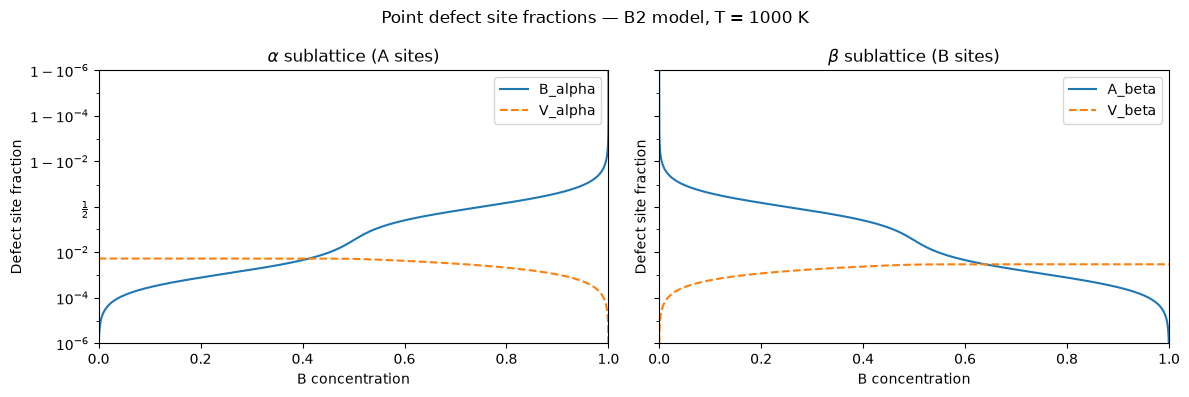

In [5]:
T = 1000  # K
dmus = np.linspace(-1.5, 1.5, 500)

# Total B concentration at each chemical potential
c_total = ab_defected.concentration(T, dmus)

def site_fractions(sublattice, T, dmus):
    """Return defect site fractions x_i^l (Eq. 3) for each defect on the sublattice."""
    zes = sublattice._get_zes(T, dmus)  # shape (n_defects, n_dmu)
    denom = 1 + zes.sum(axis=0)
    return {d.name: ze / denom for d, ze in zip(sublattice.defects, zes)}

fracs_alpha = site_fractions(alpha_sublattice, T, dmus)
fracs_beta  = site_fractions(beta_sublattice,  T, dmus)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

linestyles = ['-', '--']
for ax, fracs, title in zip(
    axes,
    [fracs_alpha, fracs_beta],
    [r'$\alpha$ sublattice (A sites)', r'$\beta$ sublattice (B sites)'],
):
    for (name, frac), ls in zip(fracs.items(), linestyles):
        ax.plot(c_total, frac, ls, label=name)
    ax.set_xlabel('B concentration')
    ax.set_ylabel('Defect site fraction')
    ax.set_title(title)
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_yscale('logit')
    ax.set_ylim(1e-6, 1 - 1e-6)

fig.suptitle(f'Point defect site fractions — B2 model, T = {T} K')
plt.tight_layout()
plt.show()

On the B-rich side ($c > 0.5$), B$_\alpha$ antisites dominate; on the A-rich side ($c < 0.5$),
A$_\beta$ antisites dominate.  The site competition captured by the denominator in Eq. (3) ensures
that defect fractions remain physically bounded even at large off-stoichiometry.

### Defect Site Fractions vs. Δμ

The same data plotted as a function of the chemical potential Δμ shows the Fermi-like
switching of defect populations directly in μ-space, without the non-linear mapping
through composition.

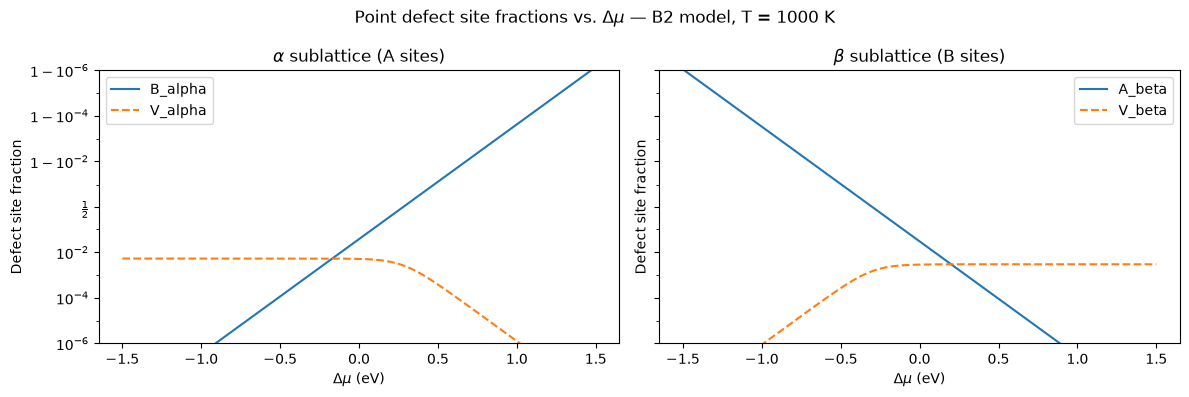

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, fracs, title in zip(
    axes,
    [fracs_alpha, fracs_beta],
    [r'$\alpha$ sublattice (A sites)', r'$\beta$ sublattice (B sites)'],
):
    for (name, frac), ls in zip(fracs.items(), linestyles):
        ax.plot(dmus, frac, ls, label=name)
    ax.set_xlabel(r'$\Delta\mu$ (eV)')
    ax.set_ylabel('Defect site fraction')
    ax.set_title(title)
    ax.legend()
    ax.set_yscale('logit')
    ax.set_ylim(1e-6, 1 - 1e-6)

fig.suptitle(rf'Point defect site fractions vs. $\Delta\mu$ — B2 model, T = {T} K')
plt.tight_layout()
plt.show()

### Terminal solid solutions and liquid

Terminal solid solutions bracket the B2 compound; a liquid phase appears at high temperature.
Parameters are chosen so that the A terminal melts at ≈ 1160 K and the B terminal at ≈ 858 K, giving an asymmetric diagram where the B2 compound remains stable up to intermediate temperatures.

In [7]:
# Terminal solid solutions
solid_a = LinePhase('A',    fixed_concentration=0, line_energy=-0.33, line_entropy=1.0*kB)
solid_b = LinePhase('B',    fixed_concentration=1, line_energy=-0.30, line_entropy=1.0*kB)
solid   = IdealSolution('solid', solid_a, solid_b)

# Liquid (higher entropy; T_melt ≈ 1160 K for A, ≈ 858 K for B)
liquid_a = LinePhase('A(l)', fixed_concentration=0, line_energy=-0.10, line_entropy=3.3*kB)
liquid_b = LinePhase('B(l)', fixed_concentration=1, line_energy=-0.13, line_entropy=3.3*kB)
liquid   = IdealSolution('liquid', liquid_a, liquid_b)

### Isothermal 1D phase diagram

Before computing the full T–c diagram, we check phase stability at a single temperature (800 K, well below the terminal melting points). `plot_1d_mu_phase_diagram` draws the semi-grand potential φ(Δμ) of each phase along the chemical-potential axis — solid where the phase is stable (lowest φ), dashed where it is metastable — with the transitions marked.

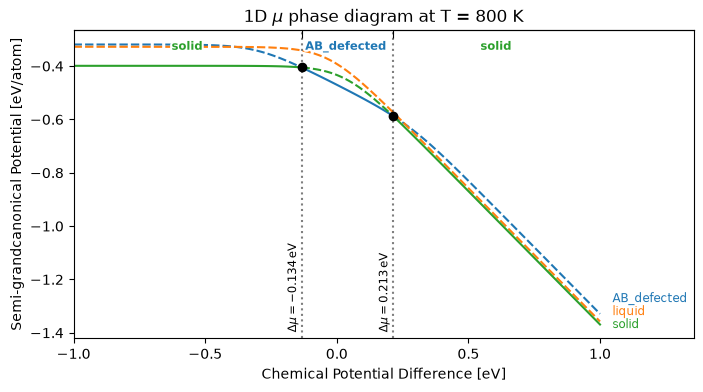

In [8]:
T_iso = 800  # K
df_1d = calc_phase_diagram([solid, liquid, ab_defected], Ts=T_iso, mu=np.linspace(-1.0, 1.0, 200), keep_unstable=True)

fig, ax = plt.subplots(figsize=(8, 4))
plot_1d_mu_phase_diagram(df_1d, ax=ax)
ax.set_title(f'1D $\\mu$ phase diagram at T = {T_iso} K')
plt.show()

### Full T–c phase diagram

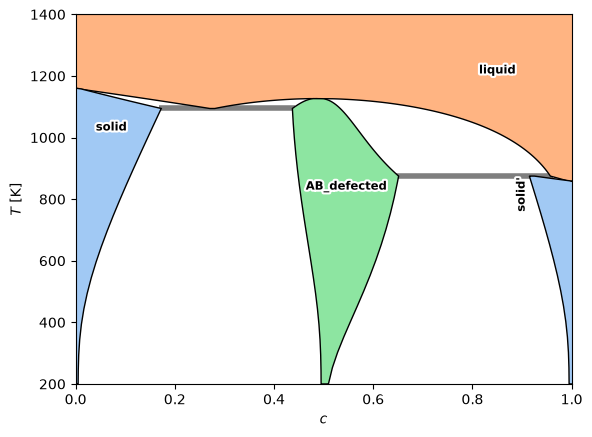

In [9]:
df = calc_phase_diagram(
    [solid, liquid, ab_defected],
    Ts=np.linspace(200, 1400, 25),
    mu=np.linspace(-0.8, 0.8, 200),
)
plot_phase_diagram(df, tielines=True)

## Low-Temperature Expansion

Equation (1) is exact for non-interacting point defects, but the per-site
$\ln(1 + \sum_i z_i)$ couples all defects on a sublattice through its denominator — the
**site competition** that keeps $\sum_i x_i^l \le 1$.  When the defects are *dilute*
($z_i = e^{-\beta[\phi_i^l]} \ll 1$, i.e. formation energies large compared to $k_B T$), the
leading term of the low-temperature expansion $\ln(1 + \sum_i z_i) \to \sum_i z_i$ drops that
coupling and leaves each defect an independent excitation with site fraction $x_i^l = z_i$:

$$\phi(\beta, \Delta\mu) = \phi_\text{host}
  - \frac{1}{\beta} \sum_l \eta_l \sum_i e^{-\beta[\phi_i^l]},
  \qquad x_i^l = e^{-\beta[\phi_i^l]}.$$

`LowTemperatureExpansionSublattice` implements this term.  It is a drop-in sibling of
`PointDefectSublattice` — both derive from `AbstractPointDefectSublattice` and consume the same
`ConstantPointDefect` objects — so a `PointDefectedPhase` can be built from either without
changing the defects.

Because the site fractions are no longer normalised they can leave $[0, 1]$ outside the dilute
regime, where the raw $\phi = -\tfrac{1}{\beta}\sum_l \eta_l \sum_i z_i$ would also run off to
$-\infty$.  To stay physical *and* thermodynamically consistent, `PointDefectedPhase` clamps the
total concentration to $[0, 1]$ and continues $\phi$ as the **tangent line** past each saturation
point — a line phase at the saturated concentration ($c = 1$ with slope $-1$, or $c = 0$ with slope
$0$).  Because $c = -\partial\phi/\partial\Delta\mu$, the clamped $c$ and the linear $\phi$ stay
consistent, and the now-bounded $\phi$ keeps an out-of-range LTE phase from spuriously dominating a
phase diagram.

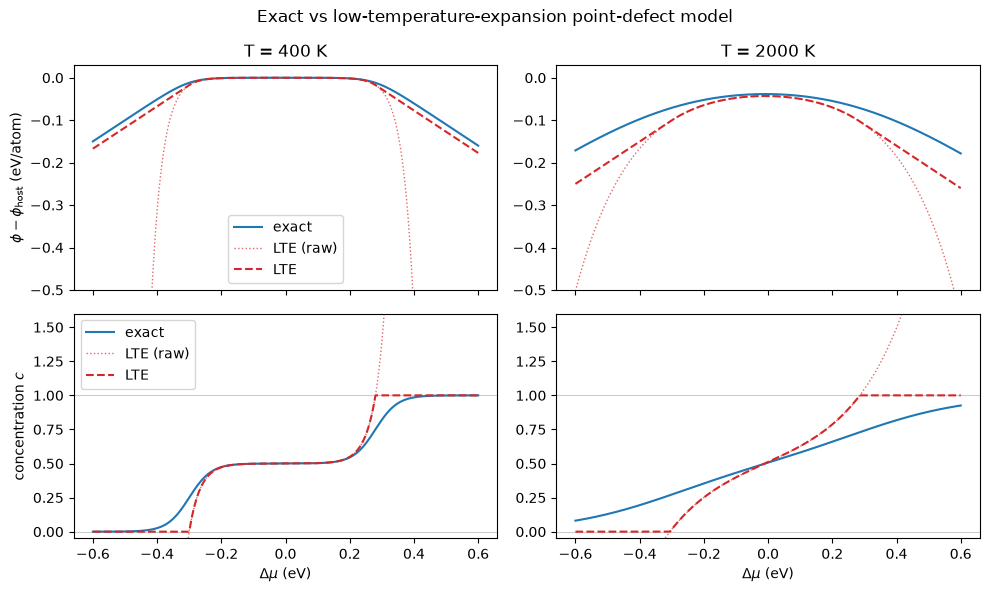

In [10]:
# Reuse the very same ConstantPointDefect objects; only the combiner changes.
ab_lte = PointDefectedPhase(
    name='AB (LTE)',
    line_phase=host,
    sublattices=[
        LowTemperatureExpansionSublattice(
            name='alpha', sublattice=0, sublattice_fraction=0.5, defects=[B_alpha, V_alpha]),
        LowTemperatureExpansionSublattice(
            name='beta', sublattice=1, sublattice_fraction=0.5, defects=[A_beta, V_beta]),
    ],
)

dmu = np.linspace(-0.6, 0.6, 600)
temps = [400, 2000]  # K: dilute vs non-dilute

fig, axes = plt.subplots(2, len(temps), figsize=(10, 6), sharex=True)
for j, T in enumerate(temps):
    phi_host = host.semigrand_potential(T, dmu)
    dphi_exact = ab_defected.semigrand_potential(T, dmu) - phi_host
    dphi_lte = ab_lte.semigrand_potential(T, dmu) - phi_host  # clamped + tangent-extended

    c_exact = ab_defected.concentration(T, dmu)
    c_lte = ab_lte.concentration(T, dmu)  # clamped to [0, 1]

    # raw, unstitched LTE (no clamp, no tangent continuation)
    c_lte_raw = host.line_concentration + sum(
        s.concentration_contribution(T, dmu) for s in ab_lte.sublattices)
    dphi_lte_raw = sum(s.semigrand_potential_contribution(T, dmu) for s in ab_lte.sublattices)

    ax_phi, ax_c = axes[0, j], axes[1, j]
    ax_phi.plot(dmu, dphi_exact, 'C0', label='exact')
    ax_phi.plot(dmu, dphi_lte_raw, 'C3:', lw=1, alpha=0.7, label='LTE (raw)')
    ax_phi.plot(dmu, dphi_lte, 'C3--', label='LTE')
    ax_phi.set_title(f'T = {T} K')
    ax_phi.set_ylim(-0.5, 0.03)

    ax_c.axhline(1, color='0.8', lw=0.8)
    ax_c.axhline(0, color='0.8', lw=0.8)
    ax_c.plot(dmu, c_exact, 'C0', label='exact')
    ax_c.plot(dmu, c_lte_raw, 'C3:', lw=1, alpha=0.7, label='LTE (raw)')
    ax_c.plot(dmu, c_lte, 'C3--', label='LTE')
    ax_c.set_xlabel(r'$\Delta\mu$ (eV)')
    ax_c.set_ylim(-0.05, 1.6)
    if j == 0:
        ax_phi.set_ylabel(r'$\phi - \phi_\mathrm{host}$ (eV/atom)')
        ax_phi.legend()
        ax_c.set_ylabel('concentration $c$')
        ax_c.legend(loc='upper left')

fig.suptitle('Exact vs low-temperature-expansion point-defect model')
plt.tight_layout()
plt.show()

At **400 K** the defects are dilute across the whole window and the expansion is
indistinguishable from the exact model.  At **2000 K** they are no longer dilute even near
stoichiometry: the raw, unstitched site fractions (dotted) overshoot $c = 1$ and send $\phi$ off to
$-\infty$.  `PointDefectedPhase` clamps $c$ to $[0, 1]$ and continues $\phi$ as the tangent line
(dashed), which keeps $c = -\partial\phi/\partial\Delta\mu$ consistent and bounds $\phi$.  The
stitched result is still only a stand-in once you leave the dilute regime — trust the expansion
where it tracks the exact curve.  Reach for `LowTemperatureExpansionSublattice` when defect
concentrations are small (the regime of most DFT-parametrised dilute-defect models) and
`PointDefectSublattice` otherwise.

### Full T–c phase diagram (low-temperature expansion)

Swapping the exact compound for its low-temperature expansion, with the same terminal `solid`
and `liquid` phases.  Over most of this temperature range the B2 defects stay dilute, so the
diagram closely matches the exact one above; the two would part where the defect populations grow
large (high $T$, far off stoichiometry).

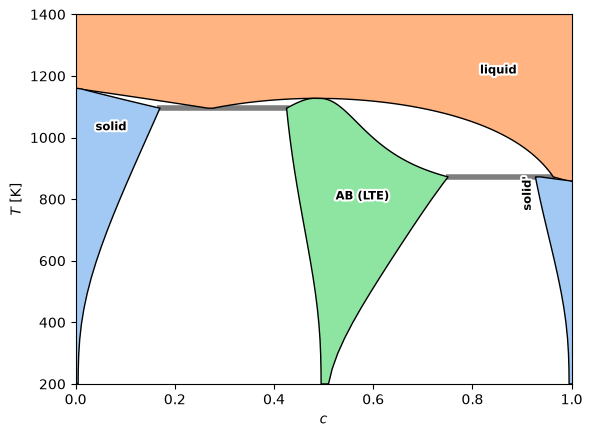

In [11]:
df_lte = calc_phase_diagram(
    [solid, liquid, ab_lte],
    Ts=np.linspace(200, 1400, 25),
    mu=np.linspace(-0.8, 0.8, 200),
)
plot_phase_diagram(df_lte, tielines=True)

## Comparing the two models' phase borders

Both models share the same host, solid and liquid phases, so those boundaries coincide and only the `AB` compound region can differ. Overplotting the stable phase-border points of the two diagrams — dropping the synthetic frame edges via the `locus` column — makes the difference directly visible: at low temperature the defects are dilute and the borders sit on top of each other, while at higher temperature the dilute expansion shifts the compound region's boundaries away from the exact model.

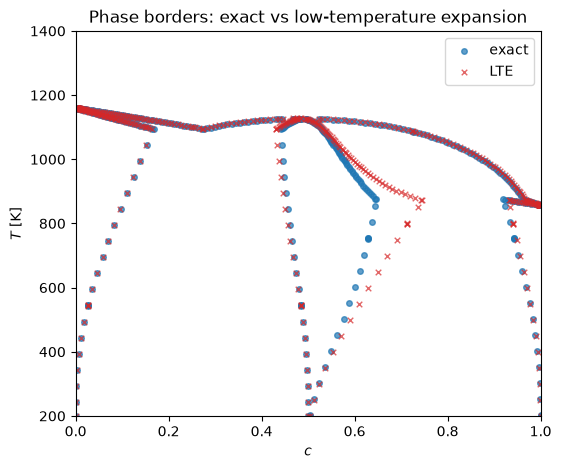

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
for diagram, color, label, marker in [(df, 'C0', 'exact', 'o'), (df_lte, 'C3', 'LTE', 'x')]:
    borders = diagram[(diagram.locus != Locus.INTERIOR) & diagram.stable]
    ax.scatter(borders.c, borders['T'], s=16, c=color, marker=marker,
               alpha=0.7, linewidths=1, label=label)
ax.set_xlim(0, 1)
ax.set_ylim(200, 1400)
ax.set_xlabel('$c$')
ax.set_ylabel('$T$ [K]')
ax.legend()
ax.set_title('Phase borders: exact vs low-temperature expansion')
plt.show()

## Parametrisation: Endmember Energies vs. Point Defect Energies

The table below shows how to convert between the two conventions for a B2 phase where the
$\alpha$-sites host A and the $\beta$-sites host B:

| CEF endmember | Composition | `PointDefectedPhase` parameters |
|--------------|------------|--------------------------------|
| A:A (all A)   | $c=0$   | $E_\text{host} + \eta_\beta\, E_{A_\beta}$ |
| A:B (stoich.) | $c=0.5$ | $E_\text{host}$ |
| B:B (all B)   | $c=1$   | $E_\text{host} + \eta_\alpha\, E_{B_\alpha}$ |

Here $\eta_\beta E_{A_\beta}$ is the excess energy per atom when every $\beta$-site carries an
A-antisite ($\eta_\beta = 0.5$ $\beta$-sites per atom, each at cost $E_{A_\beta}$).

To verify: at $T \to 0$ with $\Delta\mu$ sufficiently negative to fully populate $A_\beta$
antisites, the semi-grand potential of the defected phase should match the A:A endmember energy.

In [13]:
T_check = 10    # K — near 0 K, entropy term negligible
dmu_check = -0.35  # eV — negative enough that A_beta antisites are fully populated

# Semi-grand potential and concentration of defected phase in A-rich limit
phi_A_limit = ab_defected.semigrand_potential(T_check, dmu=dmu_check)
c_A_limit   = ab_defected.concentration(T_check, dmu=dmu_check)

# CEF A:A endmember energy from the table above (per atom)
E_host   = host.line_energy
E_A_beta = A_beta.excess_energy
eta_beta = beta_sublattice.sublattice_fraction
E_AA_endmember = E_host + eta_beta * E_A_beta  # = -0.40 + 0.5*0.30 = -0.25 eV

print(f'c at dmu={dmu_check}: {c_A_limit:.6f}  (expected ~0)')
print(f'phi(T={T_check} K, dmu={dmu_check}) = {phi_A_limit:.4f} eV')
print(f'E_AA endmember (CEF)               = {E_AA_endmember:.4f} eV')
print(f'Difference (entropy at {T_check} K)         = {phi_A_limit - E_AA_endmember:.4f} eV')

c at dmu=-0.35: 0.000000  (expected ~0)
phi(T=10 K, dmu=-0.35) = -0.2509 eV
E_AA endmember (CEF)               = -0.2500 eV
Difference (entropy at 10 K)         = -0.0009 eV


## Further Reading

- **Dissertation §11.1** (Poul 2024): Full derivation of Eqs. (1)–(4) from the semi-grand canonical partition function.
- **Khatri, Koju & Mishin (2024)** *J. Phase Equilib. Diffus.* 45, 375–393 — law-of-mass-action / Kröger–Vink approach; the semi-grand potential model above is equivalent at the ideal-mixing level.
- **Westwood et al. (2015)** *Comput. Phys. Commun.* 196, 145–151 — `pycpd` Python module implementing the dilute (low-temperature) limit.